# EEG Cognitive Load Classification with a Spiking Neural Network

This notebook builds a full pipeline for classifying cognitive load intensity from EEG data using a **Spiking Neural Network (SNN)**.

### The big picture
The STEW dataset gives us raw EEG recordings across two conditions: rest and multitask. We use **2 classes** (low vs high cognitive load) by mapping the existing subject-level labels: low workload → class 0, moderate + high → class 1. This binary setup is simpler and often more stable than a 3-class formulation.

### Why an SNN?
Standard neural nets process inputs as continuous floats. SNNs process inputs as **spike trains** — sequences of binary events over time — which is much closer to how actual neurons work. This makes them a natural fit for time-series biosignals like EEG. They're also more energy-efficient, which is why there's growing interest in them for wearable/edge BCI devices. This project is primarily used as proof of concept and to deepen my own understanding of SNNs.

### Pipeline overview
1. Load EEG data
2. Slice into epochs → extract band power features
3. Create 2-class labels (low vs high workload)
4. Rate-encode features into spike trains
5. Build and train the SNN
6. Evaluate and visualize results

## Cell 1 — Imports
Key packages:
- **`snntorch`** — the SNN framework built on top of PyTorch. Gives us LIF(Leaky Integrate and Fire) neurons and surrogate gradient support out of the box.
- **`scipy.signal.welch`** — for computing power spectral density (the basis of our band power features).
- **`sklearn`** — for normalization and train/val splitting.

If you haven't installed snntorch yet: `pip install snntorch`

In [1]:
import numpy as np
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate #Used to get the surrogate gradient function
from scipy.signal import welch #Used for feature extraction Power Spectral Density(PSD)
from scipy.io import loadmat #Only used to load .mat files, not needed if using h5py for .h5 files
import h5py #Used to load .h5 files, not needed if using scipy.io for .mat files
import scipy.io
from sklearn.preprocessing import StandardScaler #Helps with normalization
from sklearn.model_selection import train_test_split #Split data into training and validation sets
from torch.utils.data import DataLoader, TensorDataset #Turns tensors into datasets and dataloaders for training
import matplotlib.pyplot as plt #Classing visualization library


print(f"PyTorch version: {torch.__version__}")
print(f"SNNTorch version: {snn.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}") 

PyTorch version: 2.10.0+cu126
SNNTorch version: 0.9.4
CUDA available: True


## Cell 2 — Load the STEW Dataset

MATLAB `.mat` files come in different versions and the loader needs to handle both. v7.3 files use the HDF5 format under the hood, which `scipy` can't handle — so we fall back to `h5py` in that case.

After loading, we expect `eeg_matrix` to have shape `(channels, samples, subjects)`, we adjust to force `(subjects, channels, samples)`

It is noted in the data summary that there are 45 subjects and 14 channels

In [2]:
def safe_load_mat(file_path):
    """Handles both legacy .mat and v7.3 HDF5-based .mat files."""
    #Two matlab file formats: legacy (pre-7.3) and HDF5-based (7.3+). Try loading with scipy first, then fallback to h5py if needed.
    try:
        data = scipy.io.loadmat(file_path, struct_as_record=False, squeeze_me=True)
        print(f"Loaded with scipy.io.loadmat.")
        return _clean_dict(data)
    except NotImplementedError:
        print(f"v7.3 file detected. Switching to h5py...")
        with h5py.File(file_path, 'r') as f:
            return {k: np.array(v) for k, v in f.items()}
    except Exception as e:
        print(f"Load failed: {e}")
        return None

def _clean_dict(d):#Converts MATLAB structs to nested Python dicts
    for key in d:
        if isinstance(d[key], scipy.io.matlab.mio5_params.mat_struct):
            d[key] = _todict(d[key])
    return d

def _todict(matobj):#Recursively converts leftover MATLAB structs from clean_dict into dicts
    dict_out = {}
    for strname in matobj._fieldnames:
        elem = getattr(matobj, strname)
        if isinstance(elem, scipy.io.matlab.mio5_params.mat_struct):
            dict_out[strname] = _todict(elem)
        else:
            dict_out[strname] = elem
    return dict_out

# --- Load ---
clean_data   = safe_load_mat('dataset.mat')
class_data   = safe_load_mat('class_012.mat')
rating_data  = safe_load_mat('rating.mat')

eeg_matrix   = clean_data['dataset']
eeg_matrix   = np.transpose(eeg_matrix, (2, 0, 1))  # → (45, 14, 19200)

subject_labels = class_data['class_012'].squeeze().astype(int)  # (45,) values 0,1,2
ratings        = rating_data['rating'].squeeze().astype(int)    # (45,) values 1-9

print(f"EEG matrix shape:    {eeg_matrix.shape}")
print(f"Subject labels:      {subject_labels}")
print(f"Ratings:             {ratings}")
print(f"Class distribution:  {np.bincount(subject_labels)}")



Loaded with scipy.io.loadmat.
Loaded with scipy.io.loadmat.
Loaded with scipy.io.loadmat.
EEG matrix shape:    (45, 14, 19200)
Subject labels:      [2 0 0 0 1 0 1 1 1 0 1 1 1 1 2 2 1 0 2 1 2 0 0 2 0 1 1 2 1 1 0 2 0 2 2 0 2
 0 1 1 2 2 1 2 1]
Ratings:             [8 5 5 5 7 5 7 7 6 5 6 7 7 6 9 9 7 5 8 6 8 5 4 8 4 7 6 8 6 7 5 9 4 8 8 5 8
 5 6 7 8 8 7 8 7]
Class distribution:  [13 18 14]


C:\Users\20ngu\AppData\Local\Temp\ipykernel_12564\3484462440.py:18: DeprecationWarning: Please import `mat_struct` from the `scipy.io.matlab` namespace; the `scipy.io.matlab.mio5_params` namespace is deprecated and will be removed in SciPy 2.0.0.
  if isinstance(d[key], scipy.io.matlab.mio5_params.mat_struct):


## Cell 3 — Band Power Feature Extraction

Rather than feeding raw EEG samples into the SNN, we extract **band power** features. This compresses each epoch into a meaningful, compact representation based on neuroscience:

| Band | Frequency | Brain state |
|------|-----------|-------------|
| Delta | 0.5–4 Hz | Deep sleep, unconscious processing |
| Theta | 4–8 Hz | Drowsiness, memory encoding |
| **Alpha** | **8–13 Hz** | **Relaxed alertness — decreases with cognitive load** |
| **Beta** | **13–30 Hz** | **Active thinking — increases with cognitive load** |

We use **Welch's method** to estimate power — it's essentially an averaged, smoothed FFT that's much more stable than a single FFT on a short window.

Each epoch → `(n_channels × 4)` features. With 14 channels and 4 bands, that's **56 features per epoch**.

In [3]:
def extract_band_power(eeg_epoch, fs=128):
    """
    Compute band power for each channel across 4 EEG frequency bands.
    
    eeg_epoch: (n_channels, n_samples)
    returns:   (n_channels * 4,) feature vector
    """
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta':  (13, 30)
    }
    
    features = []
    n_channels = eeg_epoch.shape[0]
    
    for ch in range(n_channels):
        # nperseg=fs*2 = 2-second segments for Welch — good frequency resolution
        freqs, psd = welch(eeg_epoch[ch], fs=fs, nperseg=fs * 2)
        for band_name, (low, high) in bands.items():
            idx = np.logical_and(freqs >= low, freqs <= high)
            features.append(np.mean(psd[idx]))
    
    return np.array(features)


def create_epochs_and_features(eeg_matrix, fs=128, epoch_len_sec=2, overlap=0.5):
    """
    Slice EEG into overlapping windows and extract features from each.
    
    overlap=0.5 means 50% overlap — effectively doubles dataset size.
    Adjacent epochs will be correlated, which is acceptable here.
    """
    epoch_samples = int(epoch_len_sec * fs)           # 256 samples @ 128Hz
    step_samples  = int(epoch_samples * (1 - overlap)) # 128 samples
    
    all_features = []
    all_subject_ids = []
    
    for subj in range(eeg_matrix.shape[0]):
        eeg = eeg_matrix[subj]  # (channels, samples)
        n_samples = eeg.shape[1]
        start = 0
        while start + epoch_samples <= n_samples:
            epoch = eeg[:, start:start + epoch_samples]
            all_features.append(extract_band_power(epoch, fs=fs))
            all_subject_ids.append(subj)
            start += step_samples
    
    return np.array(all_features), np.array(all_subject_ids)


features, subject_ids = create_epochs_and_features(eeg_matrix)
print(f"Features shape: {features.shape}")
print(f"Total epochs: {len(features)} across {eeg_matrix.shape[0]} subjects")
#Expected: (n_epochs, n_features) where n_features = n_channels * 4 (bands) = 14*4=56

Features shape: (6705, 56)
Total epochs: 6705 across 45 subjects


## Cell 4 — Create 2-Class Labels

We use the existing subject-level labels from the dataset (`class_012.mat`): each subject has a workload class 0 (low), 1 (moderate), or 2 (high). For a **binary** task we map:

- **Class 0 (Low):** subject label 0  
- **Class 1 (High):** subject labels 1 and 2  

Each epoch inherits the label of the subject it came from; we then binarize so that only two classes remain. This keeps the pipeline simple and avoids the extra complexity of a 3-class setup.

Epoch class distribution → Class0 (Low): 1937 | Class1 (High): 4768


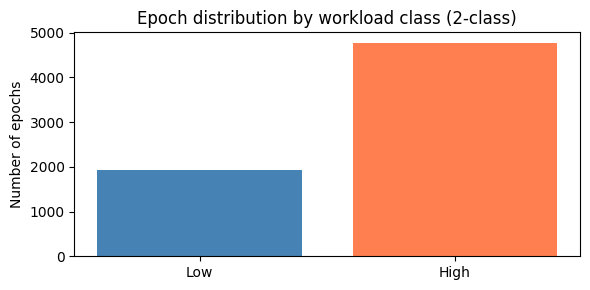

In [4]:
def create_labels_from_subjects(subject_ids, subject_labels):
    """
    Each epoch inherits the label of the subject it came from.
    We binarize: 0 → Low (0), 1 and 2 → High (1).
    subject_ids:     (n_epochs,) — which subject each epoch belongs to
    subject_labels:  (45,)      — 0/1/2 label per subject
    """
    epoch_labels = subject_labels[subject_ids]
    # Binarize: Low=0, High=1 (moderate + high both become 1)
    labels = (epoch_labels >= 1).astype(np.int64)
    
    counts = np.bincount(labels)
    print(f"Epoch class distribution → Class0 (Low): {counts[0]} | Class1 (High): {counts[1]}")
    
    plt.figure(figsize=(6, 3))
    plt.bar(['Low', 'High'], counts, color=['steelblue', 'coral'])
    plt.ylabel('Number of epochs')
    plt.title('Epoch distribution by workload class (2-class)')
    plt.tight_layout()
    plt.show()
    
    return labels

labels = create_labels_from_subjects(subject_ids, subject_labels)

## Cell 5 — Normalize Features & Rate Encode into Spike Trains

This is the step where we cross from the ANN world into the SNN world.

**Why normalize to [0, 1]?** Rate encoding works by treating each feature value as a *probability* — the probability that the corresponding input neuron fires at any given timestep. So values must be in [0, 1]. A value of 0.8 means the neuron fires on ~80% of the T timesteps; 0.1 means it fires rarely.

**The rate encoding process:**
```
For each timestep t in [1..T]:
    draw uniform random noise ~ U(0,1) for every feature
    spike = 1 if feature_value > noise else 0
```
This is stochastic — run it twice on the same input and you'll get different spike trains, but the *average* firing rate will match the original value. That stochasticity is actually a feature: it acts as a form of data augmentation and regularization.

Output shape: `(T, n_samples, n_features)` — T binary snapshots of the whole feature space.

Features min:  0.0500
Features max:  0.9500
Features mean: 0.6550
% above 0.6:   0.755
% below 0.4:   0.012


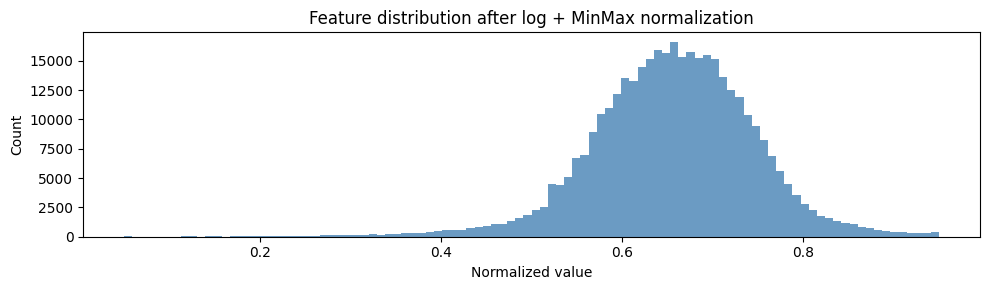

In [5]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Log-transform BEFORE normalizing.
# Band power spans many orders of magnitude (e.g. 0.001 to 10000 µV²).
# Log compresses that into a manageable range and kills outlier dominance.
# +1e-10 guards against log(0) on any zero-power values.
# Z-score each subject independently to remove inter-subject baseline differences
features_subj_norm = np.zeros_like(features)
for subj in np.unique(subject_ids):
    mask = subject_ids == subj
    subj_feats = features[mask]
    features_subj_norm[mask] = (subj_feats - subj_feats.mean(axis=0)) / (subj_feats.std(axis=0) + 1e-8)

# Then log + MinMax as before
features_log = np.log(np.abs(features_subj_norm) + 1e-10)

# Step 2: Per-feature MinMax to [0.05, 0.95]
# Each of the 56 features independently uses the full spike range.
# Slight inset from 0/1 edges — always-silent / always-firing neurons
# carry no information.
scaler = MinMaxScaler(feature_range=(0.05, 0.95))
features_norm = scaler.fit_transform(features_log)

# Diagnostic
print(f"Features min:  {features_norm.min():.4f}")   # ~0.05
print(f"Features max:  {features_norm.max():.4f}")   # ~0.95
print(f"Features mean: {features_norm.mean():.4f}")  # should be ~0.4-0.6
print(f"% above 0.6:   {(features_norm > 0.6).mean():.3f}")
print(f"% below 0.4:   {(features_norm < 0.4).mean():.3f}")

# Quick visual check — distribution should look roughly bell-shaped now
plt.figure(figsize=(10, 3))
plt.hist(features_norm.flatten(), bins=100, color='steelblue', alpha=0.8)
plt.xlabel('Normalized value')
plt.ylabel('Count')
plt.title('Feature distribution after log + MinMax normalization')
plt.tight_layout()
plt.show()

## Cell 6 — Build the Train/Val DataLoaders

Standard PyTorch DataLoader setup with a stratified train/val split to keep class proportions balanced in both sets.

One shape note: the spike data is stored as `(T, n_samples, n_features)` but DataLoaders expect the batch dimension first. We permute to `(n_samples, T, n_features)` here, then permute back inside the model's `forward()` method.

In [6]:
T = 50  # timesteps for rate encoding
BATCH_SIZE = 64

# --- Rate encode ---
# This was missing from the notebook. Do it here before the split
# so we only encode once, but index into it by subject after.
features_norm_tensor = torch.FloatTensor(features_norm)
spike_data = (torch.rand(T, len(features_norm), features_norm.shape[1]) < features_norm_tensor).float()
# shape: (T, n_epochs, n_features)

# --- Subject-based split (fixes label leakage) ---
all_subjects = np.unique(subject_ids)  # [0..44]
n_val_subjects = int(len(all_subjects) * 0.2)  # hold out ~9 subjects

rng = np.random.default_rng(42)
val_subjects = rng.choice(all_subjects, size=n_val_subjects, replace=False)
train_subjects = np.setdiff1d(all_subjects, val_subjects)

train_mask = np.isin(subject_ids, train_subjects)
val_mask   = np.isin(subject_ids, val_subjects)

# Permute: (T, n_epochs, F) → (n_epochs, T, F) for DataLoader
spike_data_batched = spike_data.permute(1, 0, 2)
labels_tensor = torch.LongTensor(labels)

train_dataset = TensorDataset(spike_data_batched[train_mask], labels_tensor[train_mask])
val_dataset   = TensorDataset(spike_data_batched[val_mask],   labels_tensor[val_mask])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)



print(f"Train subjects: {len(train_subjects)} | Val subjects: {len(val_subjects)}")
print(f"Train epochs:   {train_mask.sum()} | Val epochs: {val_mask.sum()}")
print(f"Train class dist: {np.bincount(labels[train_mask])}")
print(f"Val class dist:   {np.bincount(labels[val_mask])}")

Train subjects: 36 | Val subjects: 9
Train epochs:   5364 | Val epochs: 1341
Train class dist: [1341 4023]
Val class dist:   [596 745]


## Cell 7 — Define the SNN Architecture

The network is a 3-layer fully connected SNN using **LIF (Leaky Integrate-and-Fire)** neurons.

**How LIF neurons work:**
- Each neuron maintains a **membrane potential** (like a capacitor charging up)
- Incoming spikes add charge; the membrane **leaks** between timesteps (controlled by `beta`)
- When the membrane crosses a **threshold**, the neuron fires a spike and resets
- `beta=0.9` means 90% of charge is retained each timestep — a 10% leak rate

**The surrogate gradient trick:**
The firing event is a step function — zero gradient everywhere except a discontinuity at threshold, making standard backprop impossible. The fix: during the *backward pass only*, swap in a smooth surrogate function (here, fast sigmoid) that has a real gradient. The forward pass still uses the real step function. This is what makes training deep SNNs viable.

**Readout:** We accumulate spikes from the output layer over all T timesteps. The class with the most accumulated spikes wins — this is the "rate code" interpretation at the output too.

In [7]:

class EEG_SNN(nn.Module):
    def __init__(self, n_features, n_hidden1=128, n_hidden2=64, n_classes=2,
                 beta=0.9, T=T, dropout_p=0.3):
        super().__init__()
        self.T = T

        spike_grad = surrogate.fast_sigmoid(slope=25)

        # Layer 1
        self.fc1  = nn.Linear(n_features, n_hidden1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.dropout1 = nn.Dropout(p=dropout_p)

        # Layer 2
        self.fc2  = nn.Linear(n_hidden1, n_hidden2)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.dropout2 = nn.Dropout(p=dropout_p)

        # Output layer
        self.fc_out  = nn.Linear(n_hidden2, n_classes)
        self.lif_out = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        x = x.permute(1, 0, 2)  # (T, batch, features)

        mem1    = self.lif1.init_leaky()
        mem2    = self.lif2.init_leaky()
        mem_out = self.lif_out.init_leaky()

        spike_out_acc = 0

        for t in range(self.T):
            cur1 = self.fc1(x[t])
            spk1, mem1 = self.lif1(cur1, mem1)
            spk1 = self.dropout1(spk1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2 = self.dropout2(spk2)

            cur_out = self.fc_out(spk2)
            spk_out, mem_out = self.lif_out(cur_out, mem_out)

            spike_out_acc = spike_out_acc + spk_out

        return spike_out_acc
    

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
snn_model = EEG_SNN(n_features = 56, n_classes=2, T=T).to(DEVICE)

total_params = sum(p.numel() for p in snn_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 15,682


c:\Users\20ngu\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce RTX 5070 Laptop GPU which is of cuda capability 12.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (5.0) - (9.0)
    
  queued_call()
c:\Users\20ngu\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.8 13.0 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
c:\Users\20ngu\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
NVIDIA GeForce RTX 5070 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5070 Laptop GP

## Cell 8 — Train the SNN

The training loop is standard PyTorch with one key difference: **we feed spike trains across T timesteps** and use accumulated spike counts as logits for cross-entropy loss. CrossEntropyLoss works here because the accumulated spike counts are non-negative integers that can be treated as unnormalized class scores.

**Optimizer:** Adam with lr=1e-3. SNNs can be sensitive to learning rate — if loss doesn't decrease, try 5e-4.

**Baseline to beat:** Random chance on 2 classes = **50% accuracy**. A well-trained model should comfortably exceed 60–70% on this binary task.

In [9]:
N_EPOCHS = 50
LR       = 5e-4
DEVICE = 'cpu'
#DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'


snn_model = EEG_SNN(n_features = 56, n_classes=2, T=T).to(DEVICE)
optimizer = torch.optim.Adam(snn_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
class_counts = np.bincount(labels[train_mask])
class_weights = torch.FloatTensor(1.0 / np.sqrt(class_counts)).to(DEVICE)
class_weights = class_weights / class_weights.sum()
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
best_val_acc = 0

train_losses, val_accs = [], []

for epoch in range(N_EPOCHS):
    snn_model.train()
    epoch_loss = 0
    
    for spike_batch, label_batch in train_loader:
        spike_batch = spike_batch.to(DEVICE)
        label_batch = label_batch.to(DEVICE)
        
        optimizer.zero_grad()
        spike_counts = snn_model(spike_batch)
        loss = loss_fn(spike_counts, label_batch)
        loss.backward()
        optimizer.step()
        torch.nn.utils.clip_grad_norm_(snn_model.parameters(), 1.0)
        epoch_loss += loss.item()
    
    snn_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for spike_batch, label_batch in val_loader:
            spike_batch = spike_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)
            spike_counts = snn_model(spike_batch)
            preds = spike_counts.argmax(dim=1)
            correct += (preds == label_batch).sum().item()
            total   += len(label_batch)
    
    avg_loss = epoch_loss / len(train_loader)
    val_acc  = correct / total
    train_losses.append(avg_loss)
    val_accs.append(val_acc)

    scheduler.step(val_acc) 
# inside your epoch loop, after computing val_acc:
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
    'model_state': snn_model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'epoch': epoch,
    'val_acc': val_acc
}, 'best_checkpoint.pth')

    
    #if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1:03d}/{N_EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f}")

print(f"\nBest Val Accuracy: {max(val_accs):.3f} (epoch {np.argmax(val_accs)+1})")

Epoch 001/50 | Loss: 0.6857 | Val Acc: 0.449
Epoch 002/50 | Loss: 0.6765 | Val Acc: 0.450
Epoch 003/50 | Loss: 0.6705 | Val Acc: 0.552
Epoch 004/50 | Loss: 0.6804 | Val Acc: 0.460
Epoch 005/50 | Loss: 0.6680 | Val Acc: 0.591
Epoch 006/50 | Loss: 0.6502 | Val Acc: 0.506
Epoch 007/50 | Loss: 0.6480 | Val Acc: 0.617
Epoch 008/50 | Loss: 0.6508 | Val Acc: 0.481
Epoch 009/50 | Loss: 0.6478 | Val Acc: 0.585
Epoch 010/50 | Loss: 0.6497 | Val Acc: 0.494
Epoch 011/50 | Loss: 0.6502 | Val Acc: 0.538
Epoch 012/50 | Loss: 0.6426 | Val Acc: 0.553
Epoch 013/50 | Loss: 0.6517 | Val Acc: 0.551
Epoch 014/50 | Loss: 0.6406 | Val Acc: 0.550
Epoch 015/50 | Loss: 0.6383 | Val Acc: 0.580
Epoch 016/50 | Loss: 0.6354 | Val Acc: 0.594
Epoch 017/50 | Loss: 0.6332 | Val Acc: 0.630
Epoch 018/50 | Loss: 0.6285 | Val Acc: 0.591
Epoch 019/50 | Loss: 0.6271 | Val Acc: 0.643
Epoch 020/50 | Loss: 0.6271 | Val Acc: 0.620
Epoch 021/50 | Loss: 0.6361 | Val Acc: 0.647
Epoch 022/50 | Loss: 0.6373 | Val Acc: 0.521
Epoch 023/

In [10]:
#Training Runs with the saved best model
checkpoint = torch.load('best_checkpoint.pth')
snn_model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])

N_EPOCHS = 10

for epoch in range(N_EPOCHS):
    snn_model.train()
    epoch_loss = 0
    
    for spike_batch, label_batch in train_loader:
        spike_batch = spike_batch.to(DEVICE)
        label_batch = label_batch.to(DEVICE)
        
        optimizer.zero_grad()
        spike_counts = snn_model(spike_batch)
        loss = loss_fn(spike_counts, label_batch)
        loss.backward()
        optimizer.step()
        torch.nn.utils.clip_grad_norm_(snn_model.parameters(), 1.0)
        epoch_loss += loss.item()
    
    snn_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for spike_batch, label_batch in val_loader:
            spike_batch = spike_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)
            spike_counts = snn_model(spike_batch)
            preds = spike_counts.argmax(dim=1)
            correct += (preds == label_batch).sum().item()
            total   += len(label_batch)
    
    avg_loss = epoch_loss / len(train_loader)
    val_acc  = correct / total
    train_losses.append(avg_loss)
    val_accs.append(val_acc)

    scheduler.step(val_acc) 
# inside your epoch loop, after computing val_acc:
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
    'model_state': snn_model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'epoch': epoch,
    'val_acc': val_acc
}, 'best_checkpoint.pth')

    
    #if (epoch + 1) % 5 == 0:
    print(f"Epoch {epoch+1:03d}/{N_EPOCHS} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.3f}")

print(f"\nBest Val Accuracy: {max(val_accs):.3f} (epoch {np.argmax(val_accs)+1})")

Epoch 001/10 | Loss: 0.6231 | Val Acc: 0.615
Epoch 002/10 | Loss: 0.6175 | Val Acc: 0.597
Epoch 003/10 | Loss: 0.6238 | Val Acc: 0.595
Epoch 004/10 | Loss: 0.6231 | Val Acc: 0.584
Epoch 005/10 | Loss: 0.6189 | Val Acc: 0.604
Epoch 006/10 | Loss: 0.6205 | Val Acc: 0.626
Epoch 007/10 | Loss: 0.6251 | Val Acc: 0.637
Epoch 008/10 | Loss: 0.6179 | Val Acc: 0.647
Epoch 009/10 | Loss: 0.6190 | Val Acc: 0.588
Epoch 010/10 | Loss: 0.6203 | Val Acc: 0.639

Best Val Accuracy: 0.655 (epoch 24)


## Cell 9 — Visualize Training Results

Two plots:
1. **Training loss** — should decrease and level off. If it's still falling at epoch 30, train longer.
2. **Validation accuracy** — watch for the gap between this and training performance (overfitting signal).

**Interpreting results:**
- Stuck at ~50%? → Normalization issue or learning rate too high
- Overfitting (val acc drops while loss falls)? → Add dropout between layers
- Training slowly? → Lower T from 50 to 25 as a first experiment

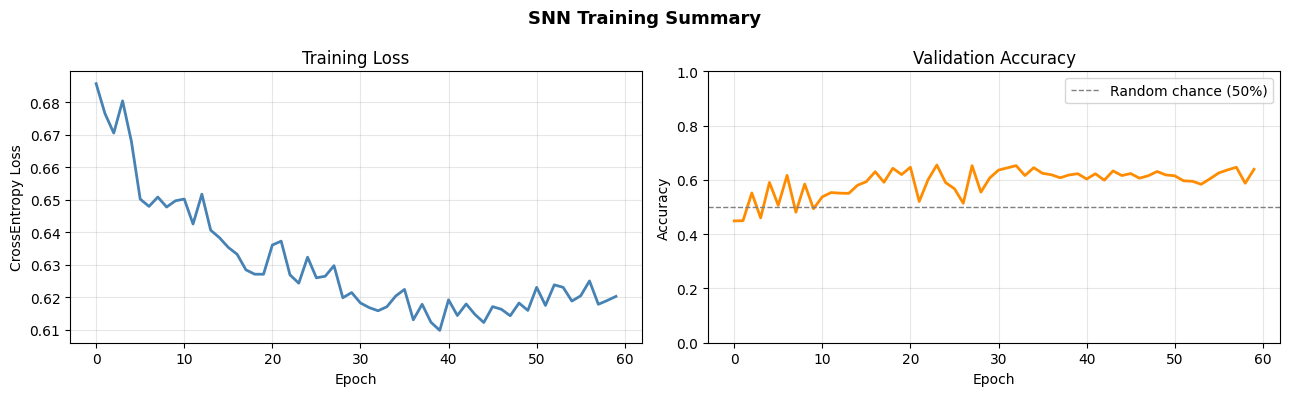

Final val accuracy: 0.639
Best val accuracy:  0.655 at epoch 24


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, color='steelblue', linewidth=2)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('CrossEntropy Loss')
ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='darkorange', linewidth=2)
ax2.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random chance (50%)')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('SNN Training Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Final val accuracy: {val_accs[-1]:.3f}")
print(f"Best val accuracy:  {max(val_accs):.3f} at epoch {np.argmax(val_accs)+1}")

## Cell 10 — Confusion Matrix

Accuracy alone doesn't tell you *where* the model is making mistakes. The confusion matrix shows which classes get confused for each other. For binary (Low vs High) cognitive load, we expect the model to separate the two classes; off-diagonal entries show misclassifications.

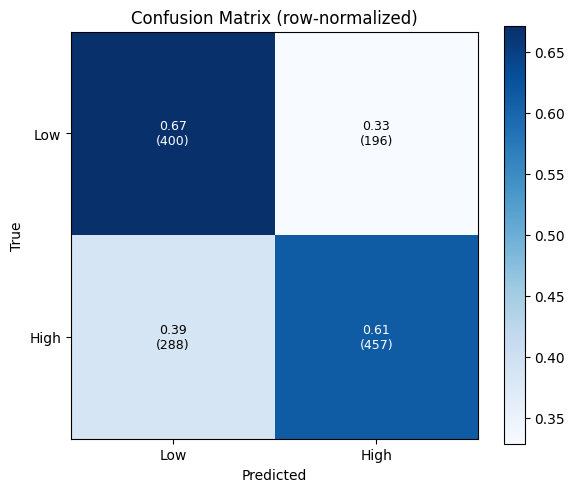

              precision    recall  f1-score   support

         Low       0.58      0.67      0.62       596
        High       0.70      0.61      0.65       745

    accuracy                           0.64      1341
   macro avg       0.64      0.64      0.64      1341
weighted avg       0.65      0.64      0.64      1341



In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import itertools

snn_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for spike_batch, label_batch in val_loader:
        spike_batch = spike_batch.to(DEVICE)
        spike_counts = snn_model(spike_batch)
        preds = spike_counts.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(label_batch.numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

class_names = ['Low', 'High']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_norm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(2)); ax.set_xticklabels(class_names)
ax.set_yticks(range(2)); ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix (row-normalized)')

for i, j in itertools.product(range(2), range(2)):
    ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})",
            ha='center', va='center',
            color='white' if cm_norm[i,j] > 0.5 else 'black', fontsize=9)

plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## Where to go from here

A few natural next experiments, roughly in order of impact:

1. **Subject-independent eval** — instead of random train/val split, hold out entire subjects for validation. This tests whether the model generalizes across people (much harder, much more useful for real BCIs).

2. **Tune `beta`** — try 0.7 vs 0.9 vs 0.95. Lower beta = more leak = the neuron forgets faster and acts more as an edge detector. Higher beta = longer temporal integration. For EEG, higher beta tends to work better.

3. **Tune `T`** — try 25, 50, 100. Plot accuracy vs. T to see the tradeoff between compute and accuracy.

4. **Add dropout** — `nn.Dropout(0.3)` between layers is the standard overfitting fix.

5. **Raw EEG input** — skip feature extraction entirely and feed raw EEG into a convolutional SNN input layer. More expressive, but needs more data and more careful preprocessing (filtering, artifact removal).

6. **Latency coding** — replace rate coding with latency coding for a completely different (and more biologically plausible) experiment. Stronger features = earlier spikes.

Also next steps

1) Github Repo this
2) Create multiple validation splits and average their results for more accurate testing
3) Graphs to see how changing beta and T affects performance over a bunch of training runs, learning rate too
4) Maybe run for a large amount of epochs and see where performance peaks